# Drosophila larval crawling analysis

Pipeline this notebook picks up from:

1. **Raspberry Pi** records each trial as an `.h264` video (3 min, 30 fps).
2. **ffmpeg** converts each video into a folder of per-frame `.png` images.
3. **The Fiji macro** (`larva_tracking.ijm`) tracks the larva in that PNG folder and saves one
   coordinates CSV per video, with columns `Frame, Time_s, X_px, Y_px, X_mm, Y_mm, Area_px, Detected`.
4. **This notebook** (using `larva_analysis.py`) cleans each CSV, computes distance/speed,
   plots trajectories, and — if you point it at a folder of many CSVs — builds one summary
   table across all your larvae with automatic QC flags.

**Before running:** make sure `larva_analysis.py` is in the same folder as this notebook
(or on your Python path), since every step below imports from it.

The cleaning logic (short-gap interpolation vs. long real gaps, and automatic outlier
rejection for false detections like debris) lives entirely in `larva_analysis.py` — see the
docstrings there for the reasoning. This notebook is just the workflow around it.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

%matplotlib inline

# Ensure Python can find larva_analysis.py whether run from python/ or repo root
for p in [Path.cwd(), Path.cwd() / 'python', Path.cwd() / 'behavior' / 'python', Path.cwd().parent / 'python']:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

try:
    from larva_analysis import (
        load_and_clean,
        compute_kinematics,
        summarize,
        summarize_by_epoch,
        plot_trajectory,
        plot_multi_larva_overlay,
        parse_filename_metadata,
        list_flagged_events,
        batch_summarize,
    )
except ImportError:
    from behavior.python.larva_analysis import (
        load_and_clean,
        compute_kinematics,
        summarize,
        summarize_by_epoch,
        plot_trajectory,
        plot_multi_larva_overlay,
        parse_filename_metadata,
        list_flagged_events,
        batch_summarize,
    )

pd.set_option('display.max_columns', None)


## Individual analysis for each video / larva

Processes each video end-to-end (trajectory, speed over time, and cumulative distance) and displays the plots for all larvae.


In [2]:
# ---- EDIT THIS CELL for your data ----
from pathlib import Path

# Search in data/csvs first (including subfolders by genotype), with fallbacks to other directories
search_folders = [Path('../data/csvs'), Path('data/csvs'), Path('behavior/data/csvs'), Path('.'), Path('..')]
available_csvs = []
for folder in search_folders:
    if folder.exists():
        # rglob finds CSVs in genotype subdirectories as well as root
        available_csvs = [p for p in sorted(folder.rglob('*.csv')) if not p.name.startswith('larva_batch_summary')]
        if available_csvs:
            break

FPS = 30                             # frames per second of the recording
MAX_GAP_FRAMES = 5                   # gaps <= this many frames get interpolated; longer gaps are left as real breaks
MAX_BRIDGE_DIST_MM = 1.0             # gaps with spatial distance <= this (mm) are bridged (joined) even if > MAX_GAP_FRAMES
MAX_SPEED_MM_S = 10.0                # velocity ceiling (mm/s) -- steps faster than this are tracking jumps, not real movement
                                     # L1 larvae crawl at ~0.5-3 mm/s; 10 mm/s is a generous physiological ceiling.
                                     # Set to None to disable velocity-based filtering.

# Optional: draw the dish edge on the trajectory plot. Leave as None to auto-detect or skip.
DISH_CENTER_MM = None   # e.g. (10.0, 10.0)
DISH_RADIUS_MM = None   # e.g. 9.5

# Optional: arena boundary filter -- detections outside the arena are wiped to NaN.
# Set to None to disable (any value > 1.0 has no effect since nothing can be that far out).
# Set to e.g. 1.0 to remove false detections strictly outside the dish edge.
# Set to e.g. 0.95 to be slightly more aggressive (5% inside the edge).
ARENA_MARGIN_FRACTION = 1.0   # None = disabled; 1.0 = remove points outside dish

print(f'Found {len(available_csvs)} CSV files for analysis.')


Found 17 CSV files for analysis.


In [3]:
# Load and clean all larvae coordinates
larva_dfs = {}
for p in available_csvs:
    df_cleaned = load_and_clean(
        p,
        fps=FPS,
        max_gap_frames=MAX_GAP_FRAMES,
        arena_margin_fraction=ARENA_MARGIN_FRACTION,
        max_bridge_dist_mm=MAX_BRIDGE_DIST_MM,
    )
    df_cleaned = compute_kinematics(df_cleaned, max_speed_mm_s=MAX_SPEED_MM_S)
    larva_dfs[p.stem] = df_cleaned

print(f'Loaded and cleaned {len(larva_dfs)} larvae.')


Loaded and cleaned 17 larvae.


### Headline numbers

`total_distance_mm` and the speed stats only use steps where both endpoints are real or
short-gap-interpolated points — a long untracked stretch never gets counted as if the larva
teleported across it. `pct_time_untracked` and `longest_untracked_stretch_s` tell you how much
of this particular video to actually trust.


In [4]:
for name, df_larva in larva_dfs.items():
    print(f'=== {name} ===')
    stats = summarize(df_larva)
    for k, v in stats.items():
        print(f"{k:30s}: {v:.4f}" if isinstance(v, (int, float, np.floating)) else f"{k:30s}: {v}")
    print()


=== N1_nSybxRalRNAiBL29580_29C_L1_FA ===
total_frames                  : 5402.0000
pct_time_untracked            : 0.0000
longest_untracked_stretch_s   : 0.0000
n_short_gaps_interpolated     : 0
n_outliers_rejected           : 0
n_speed_outliers              : 0
total_distance_mm             : 113.9854
mean_speed_mm_s               : 0.6331
median_speed_mm_s             : 0.5029
max_speed_mm_s                : 3.7607

=== N1_nSybxRalRNAiBL29580_29C_L2_FA ===
total_frames                  : 5403.0000
pct_time_untracked            : 76.7351
longest_untracked_stretch_s   : 81.8000
n_short_gaps_interpolated     : 72
n_outliers_rejected           : 0
n_speed_outliers              : 0
total_distance_mm             : 53.7919
mean_speed_mm_s               : 1.2900
median_speed_mm_s             : 0.9905
max_speed_mm_s                : 5.5891

=== N1_nSybxRalRNAiBL29580_29C_L3_FA ===
total_frames                  : 5403.0000
pct_time_untracked            : 21.0994
longest_untracked_stretch_s   :

### Flagged frames (possible false detections)

Automatic outlier rejection compares each point to the median position of its local window;
the frames it rejected are grouped into events below for a quick human sanity check — most
videos should show zero or a couple of short entries here.


In [5]:
for name, df_larva in larva_dfs.items():
    events = list_flagged_events(df_larva)
    if not events.empty:
        print(f'Flagged events for {name}:')
        print(events.to_string(index=False))
        print()
    else:
        print(f'{name}: No flagged events.\n')


N1_nSybxRalRNAiBL29580_29C_L1_FA: No flagged events.

N1_nSybxRalRNAiBL29580_29C_L2_FA: No flagged events.

N1_nSybxRalRNAiBL29580_29C_L3_FA: No flagged events.

N1_nSybxRalRNAiBL29580_29C_L4_FA: No flagged events.

N1_nSybxRalRNAiBL29580_29C_L5_FA: No flagged events.

N1_nSybxRalRNAiBL29580_29C_L6_FA: No flagged events.

Flagged events for N2_nSybxRalRNAi_L1_FA:
 start_frame  end_frame  n_frames
         748        764        17

N2_nSybxRalRNAi_L2_FA: No flagged events.

N2_nSybxRalRNAi_L3_FA: No flagged events.

Flagged events for N2_nSybxRalRNAi_L4_FA:
 start_frame  end_frame  n_frames
          12         41        30
         276        281         6

N2_nSybxRalRNAi_L5_FA: No flagged events.

N2_nSybxRalRNAi_L6_FA: No flagged events.

N2_nSybxRalRNAi_L7_FA: No flagged events.

N2_nSybxRalRNAi_L8_FA: No flagged events.

N2_nSybxRalRNAi_L9_FA: No flagged events.

N3_nSybxRalRNAi_L1_FA: No flagged events.

N3_nSybxRalRNAi_L2_FA: No flagged events.



### Trajectory plots (all larvae)

Colored by time using a standardized global color scale (0 to maximum recording duration, e.g. 180s),
so that colors correspond to the exact same timepoint across all larvae.
Any long untracked stretch is drawn as a gap in the line rather than a straight-line guess,
and discontinuities with very small spatial displacement are bridged.


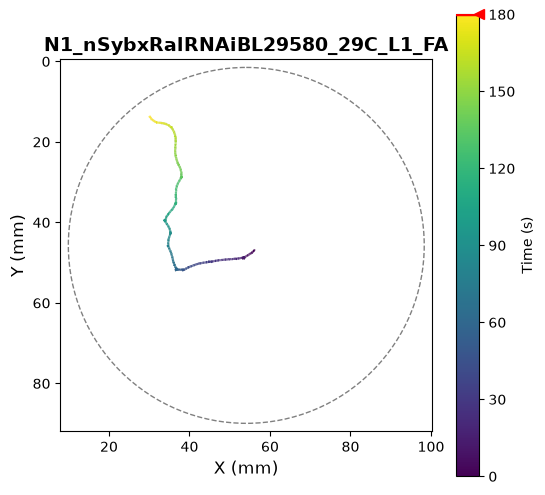

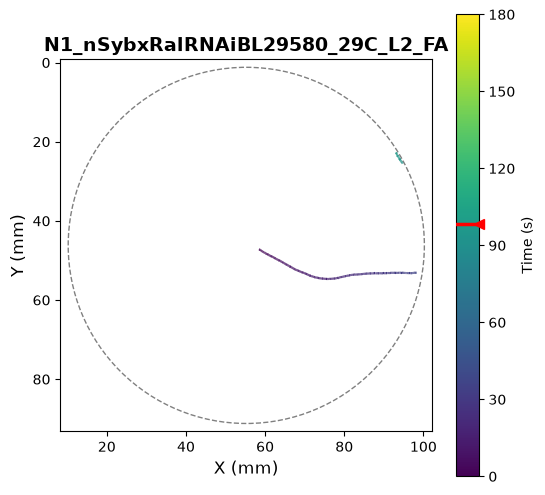

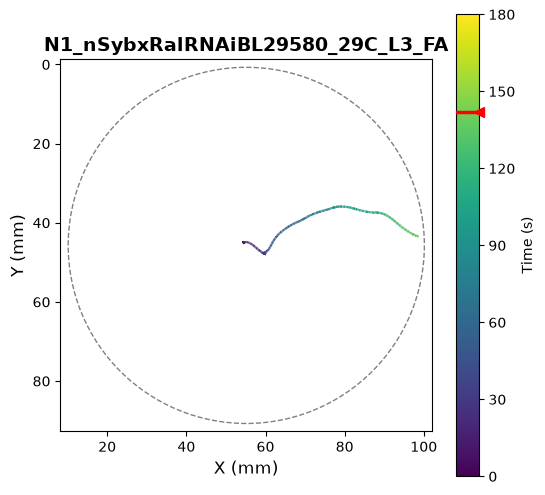

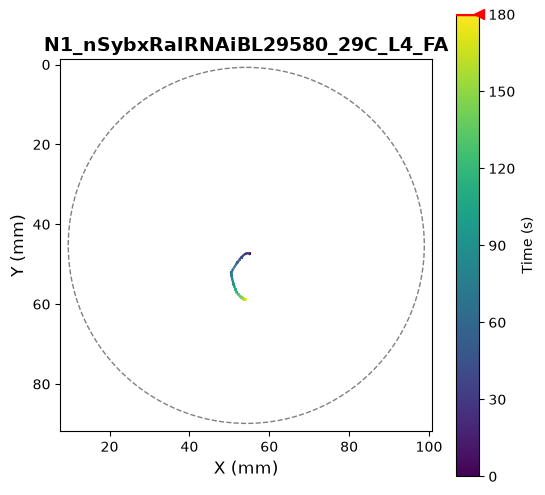

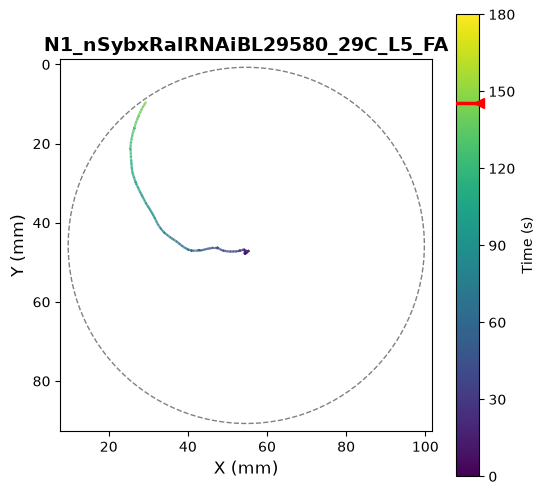

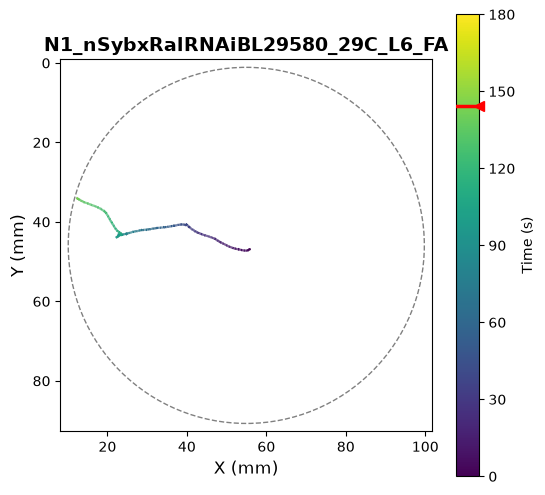

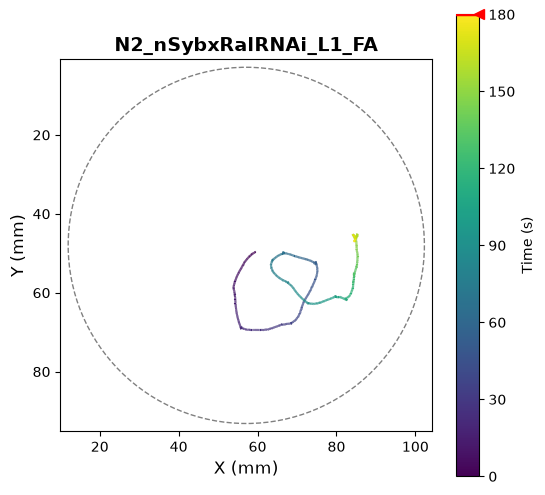

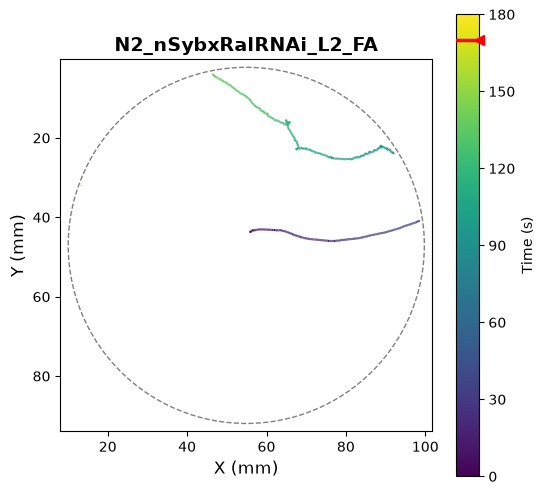

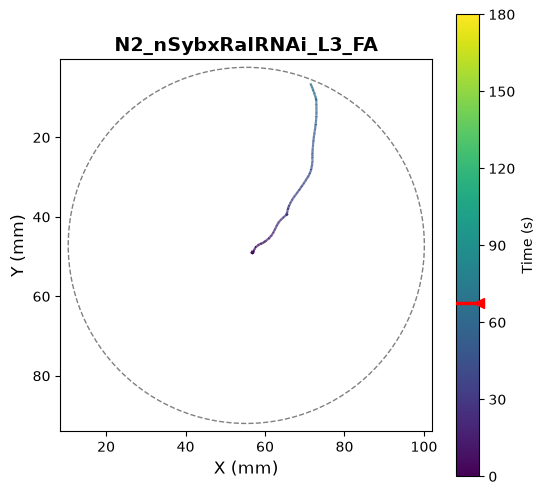

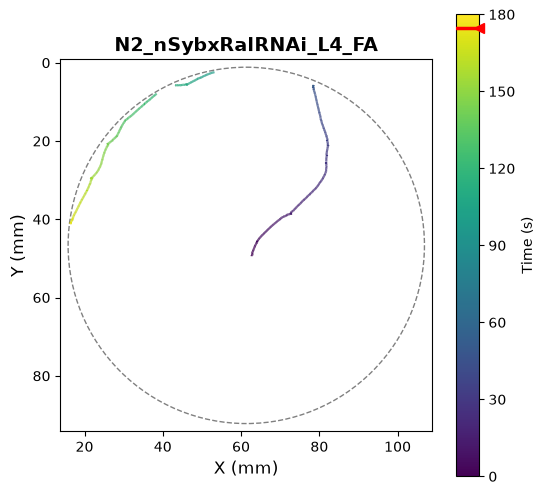

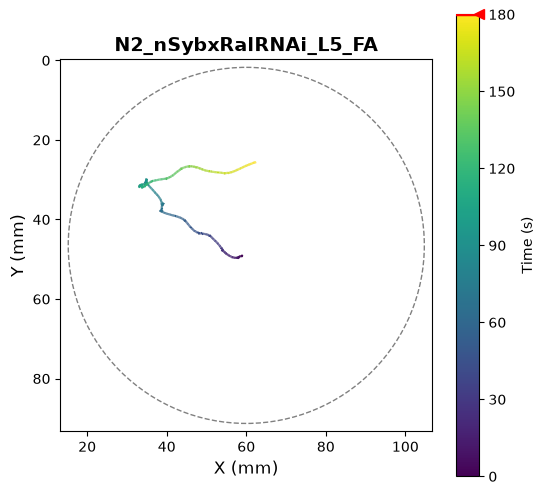

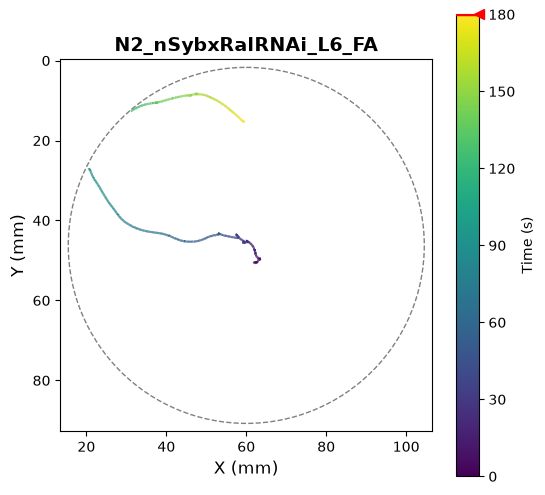

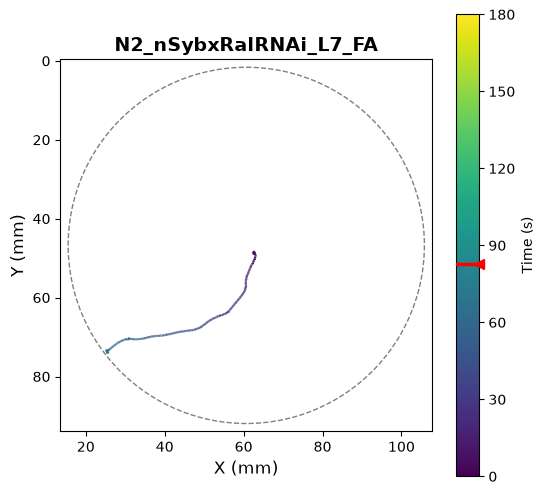

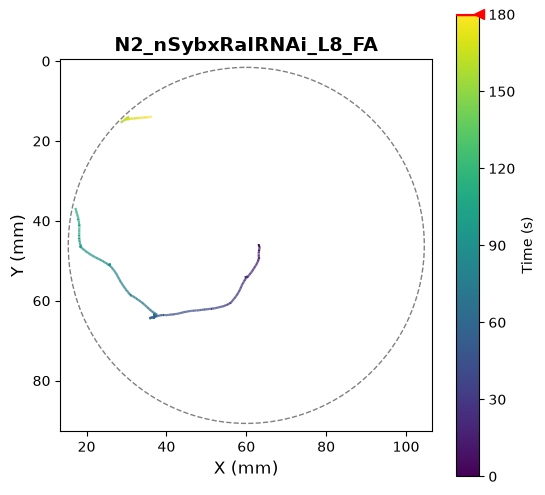

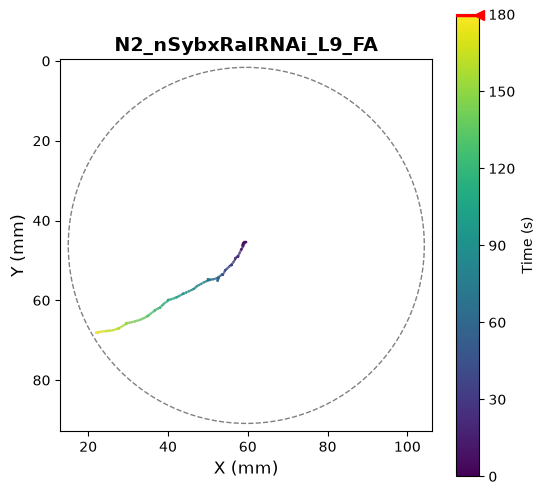

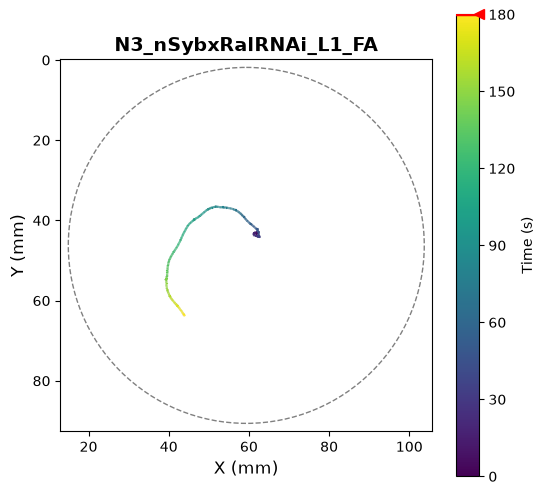

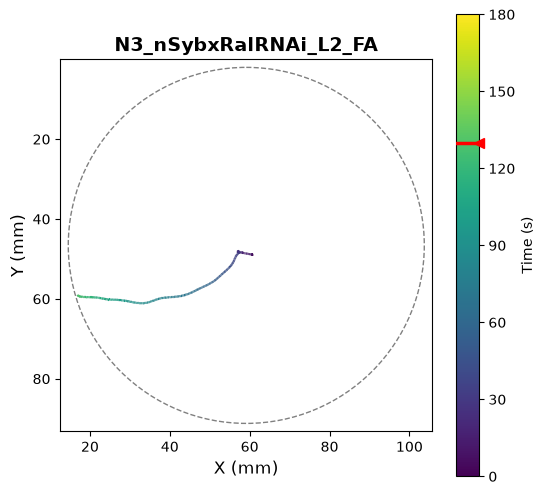

In [6]:
# Determine common time scale across all larvae (e.g. 0 to 180s)
max_recording_time_s = round(max(df["Frame"].max() / df["fps"].iloc[0] for df in larva_dfs.values()))
time_clim = (0.0, float(max_recording_time_s))

for name, df_larva in larva_dfs.items():
    fig, ax = plot_trajectory(
        df_larva,
        title=name,
        dish_center_mm=DISH_CENTER_MM,
        dish_radius_mm=DISH_RADIUS_MM,
        clim=time_clim,
    )
    plt.show()


### Speed over time (per-epoch) grouped by genotype and NX cohort

Calculates and plots the median speed across time (10s epochs) for each genotype, showing separate lines
for each experimental cohort (e.g. N1, N2, N3) with a shaded band representing the interquartile range (IQR: 25th to 75th percentiles).


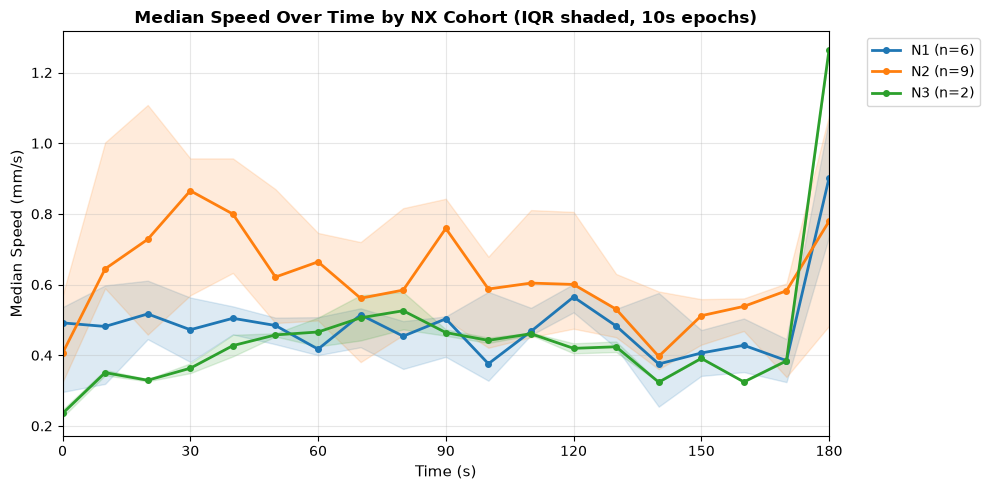

In [7]:
EPOCH_S = 10  # seconds per epoch

# Group larvae by genotype and NX cohort prefix (e.g. N1, N2, N3)
genotype_cohort_larvae = {}
for name, df_larva in larva_dfs.items():
    meta = parse_filename_metadata(name)
    genotype = df_larva.attrs.get("genotype") or meta.get("genotype") or "Unknown"
    cohort = meta.get("cohort") or "All"
    genotype_cohort_larvae.setdefault(genotype, {}).setdefault(cohort, []).append((name, df_larva))

max_t_s = int(round(max_recording_time_s))
tick_step = 30 if max_t_s >= 120 else (20 if max_t_s >= 60 else 10)
time_ticks = list(range(0, max_t_s, tick_step))
if max_t_s not in time_ticks:
    time_ticks.append(max_t_s)

for genotype, cohort_dict in sorted(genotype_cohort_larvae.items()):
    fig, ax = plt.subplots(figsize=(10, 5))
    palette = plt.cm.tab10(np.linspace(0, 1, max(10, len(cohort_dict))))

    for idx, (cohort, items) in enumerate(sorted(cohort_dict.items())):
        color = palette[idx % len(palette)]
        
        # Combine epoch stats across all larvae in this cohort
        ep_dfs = [summarize_by_epoch(df_l, epoch_s=EPOCH_S).assign(larva=n) for n, df_l in items]
        all_ep = pd.concat(ep_dfs, ignore_index=True)
        
        # Median and IQR across larvae in this cohort per epoch
        c_stats = all_ep.groupby("epoch")["median"].agg(
            median="median",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
        ).reset_index()
        
        c_stats["time_s"] = c_stats["epoch"] * EPOCH_S
        
        # Plot median line for cohort
        ax.plot(
            c_stats["time_s"],
            c_stats["median"],
            label=f"{cohort} (n={len(items)})",
            color=color,
            marker="o",
            markersize=4,
            linewidth=2,
        )
        
        # Interquartile range (IQR) band for cohort
        ax.fill_between(
            c_stats["time_s"],
            c_stats["q25"],
            c_stats["q75"],
            color=color,
            alpha=0.15,
        )

    # Standardize x-axis to show the exact full range including the maximum rounded unit
    ax.set_xlim(0, max_t_s)
    ax.set_xticks(time_ticks)

    ax.set_xlabel("Time (s)", fontsize=11)
    ax.set_ylabel("Median Speed (mm/s)", fontsize=11)
    ax.set_title(f"Median Speed Over Time - {genotype} (by NX Cohort, IQR shaded, {EPOCH_S}s epochs)", fontsize=12, weight="bold")
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left", frameon=True, fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### Cumulative distance traveled grouped by genotype and NX cohort

Calculates and plots the median cumulative distance crawled over time for each genotype, showing separate lines
for each experimental cohort (e.g. N1, N2, N3) with a shaded band representing the interquartile range (IQR: 25th to 75th percentiles).


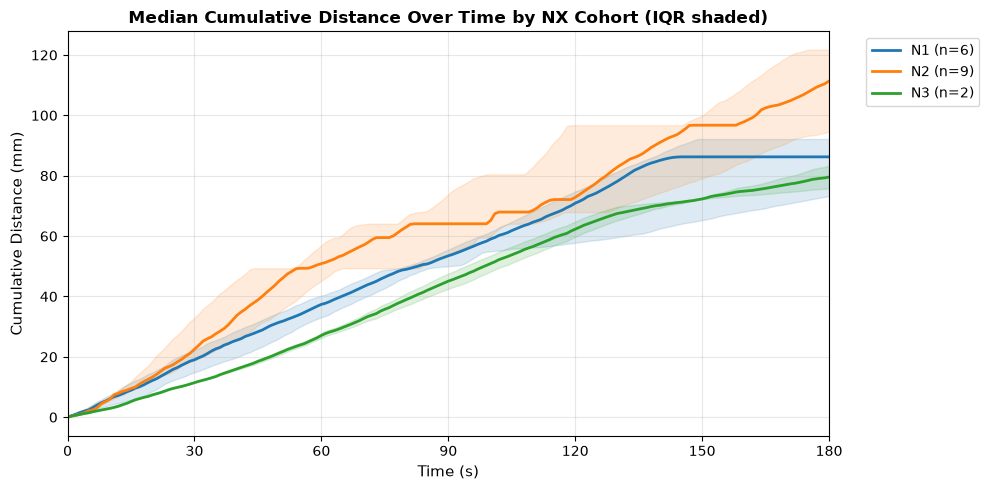

In [8]:
max_time_s = round(max(df["Frame"].max() / df["fps"].iloc[0] for df in larva_dfs.values()))
time_grid = np.linspace(0, max_time_s, int(max_time_s) + 1)
max_t_s = int(round(max_time_s))
tick_step = 30 if max_t_s >= 120 else (20 if max_t_s >= 60 else 10)
time_ticks = list(range(0, max_t_s, tick_step))
if max_t_s not in time_ticks:
    time_ticks.append(max_t_s)

for genotype, cohort_dict in sorted(genotype_cohort_larvae.items()):
    fig, ax = plt.subplots(figsize=(10, 5))
    palette = plt.cm.tab10(np.linspace(0, 1, max(10, len(cohort_dict))))

    for idx, (cohort, items) in enumerate(sorted(cohort_dict.items())):
        color = palette[idx % len(palette)]
        
        # Interpolate cumulative distance for each larva onto a common time grid
        cum_matrix = []
        for n, df_l in items:
            t = df_l["Frame"] / df_l["fps"].iloc[0]
            cd = df_l["step_dist_mm"].fillna(0).cumsum()
            cd_interp = np.interp(time_grid, t, cd)
            cum_matrix.append(cd_interp)
        
        cum_matrix = np.array(cum_matrix)
        median_cum = np.median(cum_matrix, axis=0)
        q25_cum = np.percentile(cum_matrix, 25, axis=0)
        q75_cum = np.percentile(cum_matrix, 75, axis=0)
        
        ax.plot(
            time_grid,
            median_cum,
            label=f"{cohort} (n={len(items)})",
            color=color,
            linewidth=2,
        )
        
        ax.fill_between(
            time_grid,
            q25_cum,
            q75_cum,
            color=color,
            alpha=0.15,
        )

    # Standardize x-axis to show the exact full range including the maximum rounded unit
    ax.set_xlim(0, max_t_s)
    ax.set_xticks(time_ticks)

    ax.set_xlabel("Time (s)", fontsize=11)
    ax.set_ylabel("Cumulative Distance (mm)", fontsize=11)
    ax.set_title(f"Median Cumulative Distance Over Time - {genotype} (by NX Cohort, IQR shaded)", fontsize=12, weight="bold")
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left", frameon=True, fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 2. Batch analysis (many videos / larvae at once)

Point this at a folder containing all your Fiji-macro output CSVs (one per video/larva).
Each file is run through the same cleaning + kinematics pipeline, then combined into one
summary table with automatic QC flags — videos whose numbers stand out from the rest of the
batch (not from a fixed universal cutoff, since "normal" varies by genotype/condition/setup)
get flagged for a quick visual double-check.


In [9]:
# ---- EDIT THIS CELL for your data ----

# Automatically determine the directory containing coordinate CSVs (including genotype subfolders)
candidate_csv_folders = [Path('../data/csvs'), Path('data/csvs'), Path('behavior/data/csvs'), Path('.')]
CSV_FOLDER = '.'
for cand in candidate_csv_folders:
    if cand.exists() and any(cand.rglob('*.csv')):
        CSV_FOLDER = str(cand)
        break

csv_paths = [
    p for p in sorted(Path(CSV_FOLDER).rglob('*.csv'))
    if not p.name.startswith('larva_batch_summary')
]
print(f'Using CSV_FOLDER: {CSV_FOLDER}')
print(f'Found {len(csv_paths)} CSV files:')
for p in csv_paths:
    print(' -', p.relative_to(CSV_FOLDER) if p.is_relative_to(CSV_FOLDER) else p.name)


Using CSV_FOLDER: ..\data\csvs
Found 17 CSV files:
 - N1_nSybxRalRNAiBL29580_29C_L1_FA.csv
 - N1_nSybxRalRNAiBL29580_29C_L2_FA.csv
 - N1_nSybxRalRNAiBL29580_29C_L3_FA.csv
 - N1_nSybxRalRNAiBL29580_29C_L4_FA.csv
 - N1_nSybxRalRNAiBL29580_29C_L5_FA.csv
 - N1_nSybxRalRNAiBL29580_29C_L6_FA.csv
 - N2_nSybxRalRNAi_L1_FA.csv
 - N2_nSybxRalRNAi_L2_FA.csv
 - N2_nSybxRalRNAi_L3_FA.csv
 - N2_nSybxRalRNAi_L4_FA.csv
 - N2_nSybxRalRNAi_L5_FA.csv
 - N2_nSybxRalRNAi_L6_FA.csv
 - N2_nSybxRalRNAi_L7_FA.csv
 - N2_nSybxRalRNAi_L8_FA.csv
 - N2_nSybxRalRNAi_L9_FA.csv
 - N3_nSybxRalRNAi_L1_FA.csv
 - N3_nSybxRalRNAi_L2_FA.csv


In [10]:
summary_table = batch_summarize(
    csv_paths,
    fps=FPS,
    max_gap_frames=MAX_GAP_FRAMES,
    max_speed_mm_s=MAX_SPEED_MM_S,
    arena_margin_fraction=ARENA_MARGIN_FRACTION,
    max_bridge_dist_mm=MAX_BRIDGE_DIST_MM,
)
summary_table


,total_frames,pct_time_untracked,longest_untracked_stretch_s,n_short_gaps_interpolated,n_outliers_rejected,n_speed_outliers,total_distance_mm,mean_speed_mm_s,median_speed_mm_s,max_speed_mm_s,cohort,genotype,stage,condition,replicate,noise_scale_mm,n_flagged_events,flagged,flag_reason
file,,,,,,,,,,,,,,,,,,,
..\data\csvs\N1_nSybxRalRNAiBL29580_29C_L1_FA.csv,5402,0.000000,0.000000,0,0,0,113.985398,0.633135,0.502892,3.760665,N1,nSybxRalRNAiBL29580,,,29C_L1_FA,0.008951,0,False,
..\data\csvs\N1_nSybxRalRNAiBL29580_29C_L2_FA.csv,5403,76.735147,81.800000,72,0,0,53.791911,1.289974,0.990454,5.589105,N1,nSybxRalRNAiBL29580,,,29C_L2_FA,0.004965,0,False,
..\data\csvs\N1_nSybxRalRNAiBL29580_29C_L3_FA.csv,5403,21.099389,38.000000,4,0,0,87.166896,0.613996,0.474342,3.891337,N1,nSybxRalRNAiBL29580,,,29C_L3_FA,0.008951,0,False,
..\data\csvs\N1_nSybxRalRNAiBL29580_29C_L4_FA.csv,5402,0.000000,0.000000,0,0,0,69.248852,0.384645,0.276586,7.942241,N1,nSybxRalRNAiBL29580,,,29C_L4_FA,0.012799,0,False,
..\data\csvs\N1_nSybxRalRNAiBL29580_29C_L5_FA.csv,5403,19.230057,34.633333,5,0,0,93.825561,0.645737,0.523927,3.833080,N1,nSybxRalRNAiBL29580,,,29C_L5_FA,0.007448,0,False,
..\data\csvs\N1_nSybxRalRNAiBL29580_29C_L6_FA.csv,5403,19.785304,35.633333,0,0,0,85.329275,0.590787,0.450999,3.872209,N1,nSybxRalRNAiBL29580,,,29C_L6_FA,0.007448,0,False,
..\data\csvs\N2_nSybxRalRNAi_L1_FA.csv,5402,0.000000,0.000000,17,17,0,143.525700,0.797217,0.600750,4.718400,N2,nSybxRalRNAi,L1,FA,,0.002483,1,False,
..\data\csvs\N2_nSybxRalRNAi_L2_FA.csv,5402,50.092558,47.500000,0,0,0,127.869193,1.424462,1.224132,5.846383,N2,nSybxRalRNAi,L2,FA,,0.007448,0,True,unusually fast median speed
..\data\csvs\N2_nSybxRalRNAi_L3_FA.csv,5404,62.768320,112.500000,13,0,0,64.076076,0.955884,0.764853,6.413267,N2,nSybxRalRNAi,L3,FA,,0.004965,0,False,


In [11]:
#flagged = summary_table[summary_table["flagged"]]
#print(f"{len(flagged)} of {len(summary_table)} videos flagged for a manual check:")
#flagged[["flag_reason"]]


### Comparing larvae: distance and speed

Bar chart of total distance per larva, plus a boxplot of per-frame speeds so you can see
spread as well as central tendency.


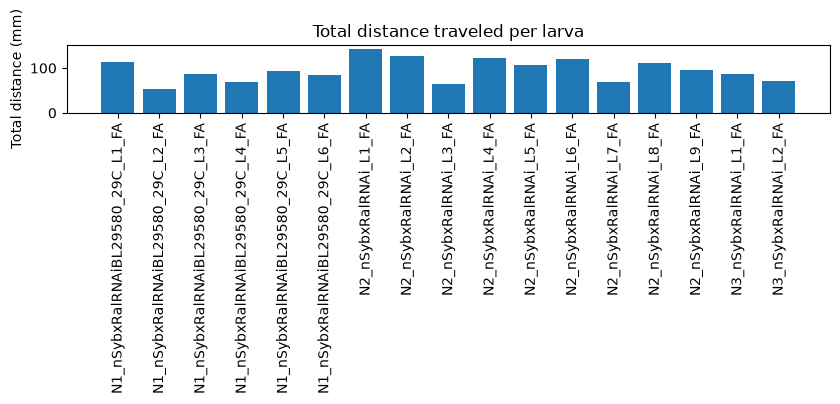

In [12]:
fig, ax = plt.subplots(figsize=(max(6, 0.5 * len(summary_table)), 4))
labels = [Path(f).stem for f in summary_table.index]
ax.bar(labels, summary_table["total_distance_mm"], color="tab:blue")
ax.set_ylabel("Total distance (mm)")
ax.set_title("Total distance traveled per larva")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


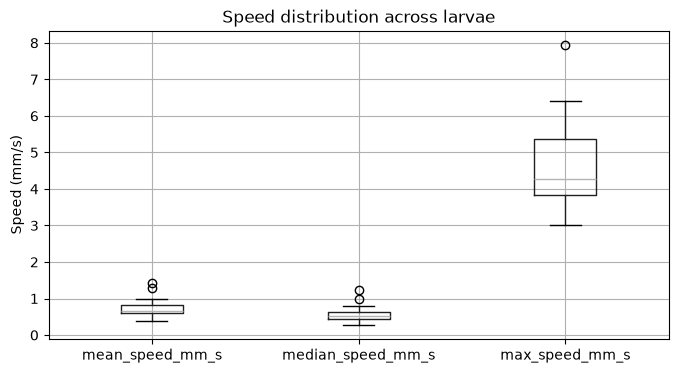

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
speed_cols = ["mean_speed_mm_s", "median_speed_mm_s", "max_speed_mm_s"]
summary_table[speed_cols].boxplot(ax=ax)
ax.set_ylabel("Speed (mm/s)")
ax.set_title("Speed distribution across larvae")
plt.show()


### Save the batch summary

Writes the full summary table (including QC flags) to a CSV and an Excel file next to this
notebook.


In [14]:
results_folder = Path('../data/results') if Path('../data/results').exists() else Path('data/results') if Path('data/results').exists() else Path('.')
summary_csv_path = results_folder / 'larva_batch_summary.csv'
summary_xlsx_path = results_folder / 'larva_batch_summary.xlsx'
summary_table.to_csv(summary_csv_path)
summary_table.to_excel(summary_xlsx_path)
print(f'Saved {summary_csv_path} and {summary_xlsx_path}')


Saved ..\data\results\larva_batch_summary.csv and ..\data\results\larva_batch_summary.xlsx


### Multi-Larva Trajectory Overlay (Arena-Centered)

This reproduces the multi-larva overlay plot (as in Empty_Trajectories.ipynb and Hid_all_larvae_inferno.png).
Each larva trajectory is re-centered around the arena origin (0, 0) and plotted together
with a circular arena boundary and distinct colors from the chosen colormap.


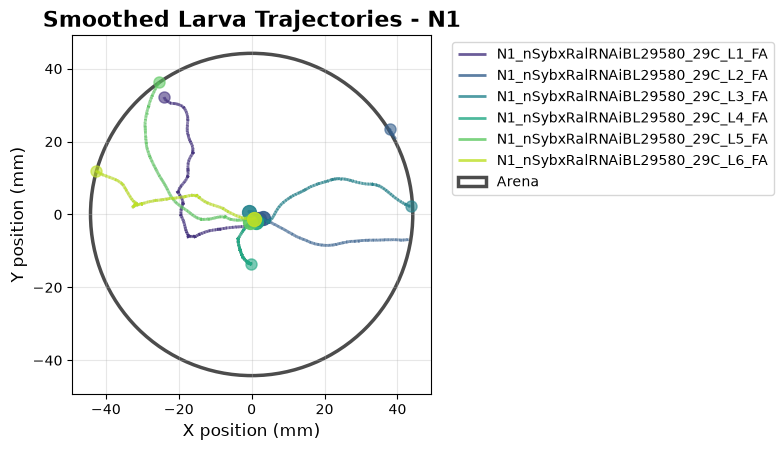

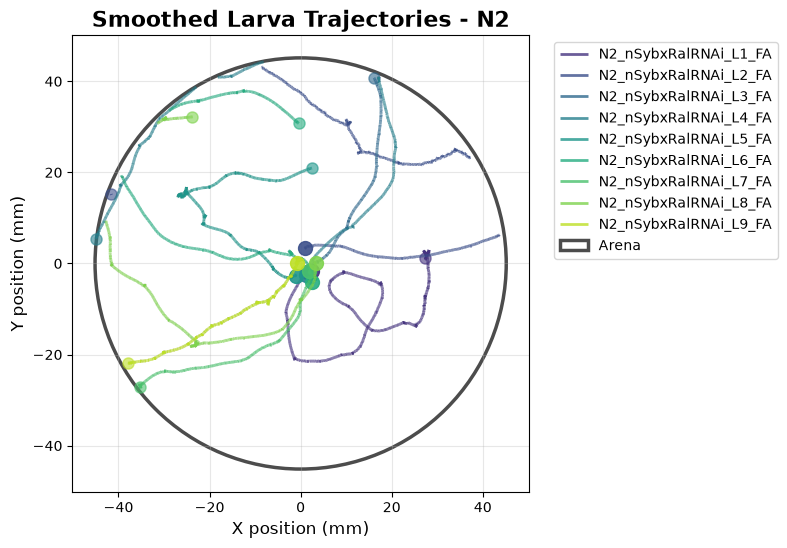

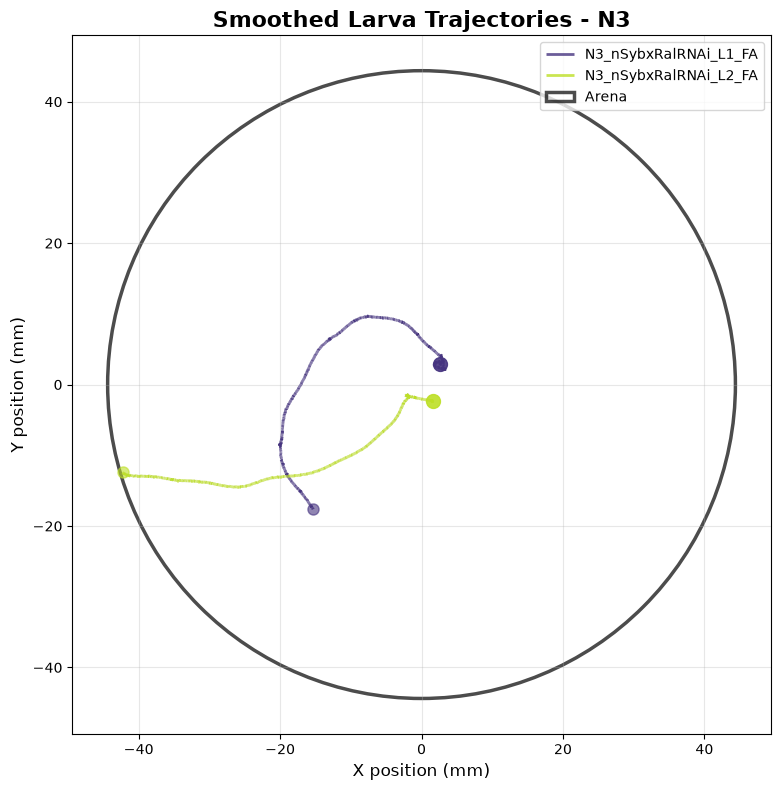

In [15]:
# Load ALL larvae and group by genotype and NX cohort
genotype_cohort_overlay = {}

for p in csv_paths:
    df_larva = larva_dfs.get(p.stem) if p.stem in larva_dfs else load_and_clean(
        p, fps=FPS, max_gap_frames=MAX_GAP_FRAMES,
        arena_margin_fraction=ARENA_MARGIN_FRACTION,
        max_bridge_dist_mm=MAX_BRIDGE_DIST_MM
    )
    if p.stem not in larva_dfs:
        df_larva = compute_kinematics(df_larva, max_speed_mm_s=MAX_SPEED_MM_S)
    
    meta = parse_filename_metadata(p)
    genotype = df_larva.attrs.get("genotype") or meta.get("genotype") or "Unknown"
    cohort = meta.get("cohort") or "All"
    label = meta.get("stem", p.stem)
    
    genotype_cohort_overlay.setdefault(genotype, {}).setdefault(cohort, {"dfs": [], "labels": []})
    genotype_cohort_overlay[genotype][cohort]["dfs"].append(df_larva)
    genotype_cohort_overlay[genotype][cohort]["labels"].append(label)

results_folder = Path("../data/results") if Path("../data/results").exists() else Path("data/results") if Path("data/results").exists() else Path(".")

# Multi-larva arena-centered overlay plot for EACH genotype and NX cohort
for genotype, cohort_dict in sorted(genotype_cohort_overlay.items()):
    for cohort in sorted(cohort_dict.keys()):
        c_data = cohort_dict[cohort]
        c_save_path = results_folder / f"{genotype}_{cohort}_larvae_trajectory_overlay.png"
        fig, ax = plot_multi_larva_overlay(
            c_data["dfs"],
            labels=c_data["labels"],
            title=f"Smoothed Larva Trajectories - {genotype} {cohort}",
            palette_name="viridis",
            save_path=str(c_save_path),
        )
        plt.show()


## Notes / parameters you may want to tune

- **`MAX_GAP_FRAMES`** — how many consecutive undetected frames still count as a "blip" to
  interpolate through, vs. a real loss of tracking (e.g. larva at the dish wall) that's left
  as a gap and excluded from distance/speed.
- **Outlier rejection threshold** — set automatically per video in `load_and_clean`
  (`deviation_multiplier`, `min_deviation_floor_mm`, `local_window` arguments), so a noisier
  video gets a looser threshold rather than one fixed number for every video. Override
  `max_local_deviation_mm` directly if you want the same fixed threshold everywhere instead.
- **`EPOCH_S`** — length of the time bins used for the per-epoch speed summary.
- Re-run `list_flagged_events(df)` for any individual video whose batch row got flagged, to see
  exactly which frames were rejected before deciding whether to trust it.
